# 04 — Modelling

Builds the model ladder. Each rung adds information; the comparison is between
**feature sets**, not between algorithms.

| # | Features | Question |
|---|---|---|
| 0 | constant (train median) | What does predicting nothing cost? |
| 1 | `vote_average` only | Am I just an average viewer? |
| 2 | Block F — film metadata | Does knowing what kind of film it is beat the crowd? |
| 3 | + Block H — personal history | Does my viewing history add anything? |
| 4 | + Block R — review-derived | Does what I've written add anything beyond what I've rated? |

**Input:** `data/interim/modelling_base.csv`

Two model families throughout — Ridge and Random Forest — with the same
hyperparameter budget at every rung, so the comparison stays about features.

## 1. Load and split

Chronological 80/20. Re-sorted on load because CSV round-trips can reorder, and
chronological order is load-bearing.

Date ranges printed separately as visible confirmation the two periods don't overlap.


In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


df = pd.read_csv("data/interim/modelling_base.csv", parse_dates=["watched_date"])
df = df.sort_values("watched_date").reset_index(drop=True)

split_idx = int(len(df) * 0.8)
train = df[:split_idx].copy()
test  = df[split_idx:].copy()

print(f"train {len(train)}  test {len(test)}")
print(f"train: {train['watched_date'].min().date()} -> {train['watched_date'].max().date()}")
print(f"test : {test['watched_date'].min().date()} -> {test['watched_date'].max().date()}")

train 953  test 239
train: 2021-12-25 -> 2024-09-27
test : 2024-10-03 -> 2026-08-31


## 2. Evaluation

Written once and reused for every model, so every rung is scored identically.

`round(pred * 2) / 2` snaps a continuous prediction to the nearest half-star;
`clip` keeps it inside the valid 0.5–5.0 range, since a model can predict 5.3.

Both raw and rounded MAE are reported — rounding can move the number in either
direction. `exact` and `within_half` are the interpretable metrics: what fraction land
on the precise half-star, and what fraction are within one.


In [2]:
def evaluate(y_true, y_pred, name=""):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    rounded = np.clip(np.round(y_pred * 2) / 2, 0.5, 5.0)

    return {
        "model":        name,
        "MAE":          np.abs(y_true - y_pred).mean(),
        "RMSE":         np.sqrt(((y_true - y_pred) ** 2).mean()),
        "MAE_rounded":  np.abs(y_true - rounded).mean(),
        "exact":        (rounded == y_true).mean(),
        "within_half":  (np.abs(y_true - rounded) <= 0.5).mean(),
    }

## 3. Model 0 — the baseline

Predicting the training median for every test film. Every later model is measured
against this.

`results` is a running list so each model appends to it and the comparison table
builds itself.


In [3]:
results = []

baseline = train["rating"].median()
pred_0 = np.full(len(test), baseline)
results.append(evaluate(test["rating"], pred_0, "0 — constant (train median)"))

pd.DataFrame(results).round(3)

,model,MAE,RMSE,MAE_rounded,exact,within_half
0,0 — constant (train median),0.682,0.871,0.682,0.197,0.632


Predicting 3.5 for everything hits the exact rating 19.7% of the time and lands
within half a star 63.2% of the time. Worth stating plainly in the presentation — it
frames the difficulty better than an MAE alone.

`MAE` and `MAE_rounded` are identical here because 3.5 is already a valid half-star.
They diverge once models predict continuous values.


## 4. Model 1 — crowd score only

A one-feature linear regression rather than the raw halved TMDB score, so the model
learns the scaling and any systematic offset itself.


In [4]:
X1_train = train[["vote_average"]]
X1_test  = test[["vote_average"]]

m1 = LinearRegression().fit(X1_train, train["rating"])
pred_1 = m1.predict(X1_test)

results.append(evaluate(test["rating"], pred_1, "1 — crowd score only"))
print(f"slope {m1.coef_[0]:.3f}  intercept {m1.intercept_:.3f}")
pd.DataFrame(results).round(3)

slope 0.598  intercept -0.716


,model,MAE,RMSE,MAE_rounded,exact,within_half
0,0 — constant (train median),0.682,0.871,0.682,0.197,0.632
1,1 — crowd score only,0.656,0.826,0.659,0.213,0.636


**Slope 0.598.** On TMDB's 0–10 scale, a one-point rise moves the predicted
rating by 0.6 stars — equivalent to 1.19 on a like-for-like scale. So personal ratings
move *more* than crowd scores do, not less.

TMDB scores cluster tightly (most films between 6 and 8), so the model has to amplify
small differences in a narrow input to predict a wide output. It is stretching a
compressed signal.

`within_half` barely moved (63.2% → 63.6%), so the crowd score is shaving large errors
rather than producing more close predictions.


## 5. Bootstrap confidence intervals

The 239 test films are one sample from the many test sets that might have occurred.
Resampling them with replacement and recomputing MAE shows how much the number would
wobble under a different draw.

`rng.integers(0, n, n)` draws n indices with replacement — some films appear twice,
some not at all — which is what makes each resample a plausible alternative test set.


In [5]:
def bootstrap_mae(y_true, y_pred, n_boot=2000, seed=0):
    """95% confidence interval for MAE by resampling the test set."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    rng = np.random.default_rng(seed)

    n = len(y_true)
    maes = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, n)
        maes[i] = np.abs(y_true[idx] - y_pred[idx]).mean()

    return np.percentile(maes, [2.5, 97.5])

In [6]:
for name, pred in [("Model 0", pred_0), ("Model 1", pred_1)]:
    lo, hi = bootstrap_mae(test["rating"], pred)
    print(f"{name}: MAE {np.abs(test['rating'] - pred).mean():.3f}  95% CI [{lo:.3f}, {hi:.3f}]")

Model 0: MAE 0.682  95% CI [0.615, 0.751]
Model 1: MAE 0.656  95% CI [0.596, 0.721]


The two intervals overlap almost entirely, so Model 1's 0.027 gain is **not**
distinguishable from noise.

Intervals are roughly ±0.06 wide, which sets the bar for the whole project: a model
needs to beat the baseline by something like 0.05+ before the improvement can be
claimed.


### Paired comparison

Comparing two independent intervals is conservative — the models predict the **same**
films, so their errors are correlated. Resampling the same indices for both cancels
the shared difficulty of the films and gives a more sensitive test.

If the interval for the *difference* excludes zero, the improvement is real even when
the individual intervals overlap.


In [7]:
def bootstrap_mae_diff(y_true, pred_a, pred_b, n_boot=2000, seed=0):
    """95% CI for MAE(a) - MAE(b), resampling the same films for both."""
    y_true = np.asarray(y_true)
    err_a = np.abs(y_true - np.asarray(pred_a))
    err_b = np.abs(y_true - np.asarray(pred_b))
    rng = np.random.default_rng(seed)

    n = len(y_true)
    diffs = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, n)
        diffs[i] = err_a[idx].mean() - err_b[idx].mean()

    return diffs.mean(), np.percentile(diffs, [2.5, 97.5])

In [8]:
diff, (lo, hi) = bootstrap_mae_diff(test["rating"], pred_0, pred_1)
print(f"Model 0 - Model 1: {diff:+.3f}  95% CI [{lo:+.3f}, {hi:+.3f}]")

Model 0 - Model 1: +0.025  95% CI [-0.022, +0.074]


Spans zero. Even paired, the crowd score does not reliably beat predicting the
median.

This is a useful early result: **Model 1 is a weak baseline**, meaning the crowd score
barely knows this viewer. That leaves substantial room for the personal feature blocks.


---

## 6. Block F — film metadata

### Genre vocabulary

Derived from **training data only**. Building it from the full dataset would create
columns for genres that appear only in test films — a leak, and one that breaks when
the model is later applied to unseen films.

`min_count=20` matches the EDA threshold: a genre with three films cannot support a
stable estimate and only adds a near-empty column. Rare genres get no column, and
those films are represented by their other genres.


In [9]:
def genre_vocabulary(series, min_count=20):
    counts = (series.fillna("").str.split("|").explode()
              .replace("", np.nan).dropna().value_counts())
    return sorted(counts[counts >= min_count].index)

GENRES = genre_vocabulary(train["genres"])
print(f"{len(GENRES)} genres: {GENRES}")

15 genres: ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Mystery', 'Romance', 'Science Fiction', 'Thriller', 'War']


In [10]:
def count_uncovered(series, vocab):
    has_none = series.fillna("").apply(
        lambda s: not any(g in s.split("|") for g in vocab))
    return has_none.sum()

print(f"train films with no vocabulary genre: {count_uncovered(train['genres'], GENRES)}")
print(f"test  films with no vocabulary genre: {count_uncovered(test['genres'], GENRES)}")

train films with no vocabulary genre: 2
test  films with no vocabulary genre: 3


Only 5 films of 1,192 end up with no vocabulary genre, so the threshold is not
too aggressive.


### Multi-hot encoding

**Multi-hot, not one-hot.** One-hot assumes exactly one category per row; genres are
multi-label — *Dune* is Science Fiction *and* Adventure, so both columns fire.

This also means there is no dummy variable trap: knowing a film is not Drama or Comedy
tells you nothing about whether it is Horror, so all 15 columns are kept.

`vocab` is a parameter rather than a global, which is what allows the same columns to
be produced for train, test, and later unseen films.


In [11]:
def encode_genres(series, vocab):
    """One binary column per genre in the vocabulary."""
    split = series.fillna("").str.split("|")
    return pd.DataFrame(
        {f"genre_{g}": split.apply(lambda gs: int(g in gs)) for g in vocab},
        index=series.index,
    )

g_train = encode_genres(train["genres"], GENRES)
print(g_train.shape)
print(g_train.sum().sort_values(ascending=False).head())

(953, 15)
genre_Drama       617
genre_Comedy      241
genre_Thriller    238
genre_Romance     164
genre_Crime       148
dtype: int64


### Language

Genuinely one-hot — a film has exactly one original language — but high-cardinality,
so it needs a top-N treatment.

`pd.get_dummies` is avoided deliberately: it builds columns from whatever data it is
given, so train and test would produce different column sets. It would also give a
column to languages with two or three films, which is noise a model can overfit.
(`sklearn`'s `OneHotEncoder(handle_unknown="ignore")` is the production equivalent;
hand-rolling here makes the train-fitted vocabulary explicit.)


In [12]:
def top_n_vocabulary(series, n=10, min_count=15):
    """Most frequent values in the training data, above a minimum count."""
    counts = series.dropna().value_counts()
    return sorted(counts[counts >= min_count].head(n).index)

LANGUAGES = top_n_vocabulary(train["original_language"], n=10)
print(f"{len(LANGUAGES)} languages: {LANGUAGES}")
print()
print(train["original_language"].value_counts().head(15))

5 languages: ['en', 'fr', 'ja', 'ko', 'zh']

original_language
en    767
ja     45
fr     38
ko     19
zh     15
de      9
es      8
it      8
sv      8
da      5
cn      4
ru      4
pl      4
el      3
no      2
Name: count, dtype: int64


The `min_count=15` floor binds before the `n=10` cap — German at 9 films is the
first exclusion. Five columns plus an implicit "other" covering ~60 films.

English dominates at 767 of 953 films (80%), so realistically the model learns
"English vs not" and the finer distinctions stay weak.


In [13]:
def encode_categorical(series, vocab, prefix):
    """One binary column per vocabulary value, plus an 'other' catch-all."""
    out = pd.DataFrame(
        {f"{prefix}_{v}": (series == v).astype(int) for v in vocab},
        index=series.index,
    )
    out[f"{prefix}_other"] = (~series.isin(vocab)).astype(int)
    return out

l_train = encode_categorical(train["original_language"], LANGUAGES, "lang")
print(l_train.shape)
print(l_train.sum())

(953, 6)
lang_en       767
lang_fr        38
lang_ja        45
lang_ko        19
lang_zh        15
lang_other     69
dtype: int64


The explicit `other` column matters: without it, a film in an excluded language
would be all-zeros across every language column, indistinguishable from missing data.


### Numeric features

Distributions inspected **before** deciding on transforms.


In [14]:
CANDIDATES = ["runtime", "vote_average", "vote_count", "popularity",
              "film_year", "review_words"]

print(train[CANDIDATES].describe().round(2))


       runtime  vote_average  vote_count  popularity  film_year  review_words
count   953.00        953.00      953.00      953.00     953.00        953.00
mean    117.58          7.18     4719.56       11.36    2004.60        111.75
std      25.46          0.66     5358.05       10.02      18.29        107.80
min      45.00          4.29       12.00        0.32    1931.00          1.00
25%     100.00          6.79     1098.00        5.05    1996.00         26.00
50%     114.00          7.23     2989.00        8.36    2010.00         84.00
75%     131.00          7.64     6322.00       14.45    2019.00        164.00
max     345.00          8.69    40184.00       81.22    2024.00        861.00


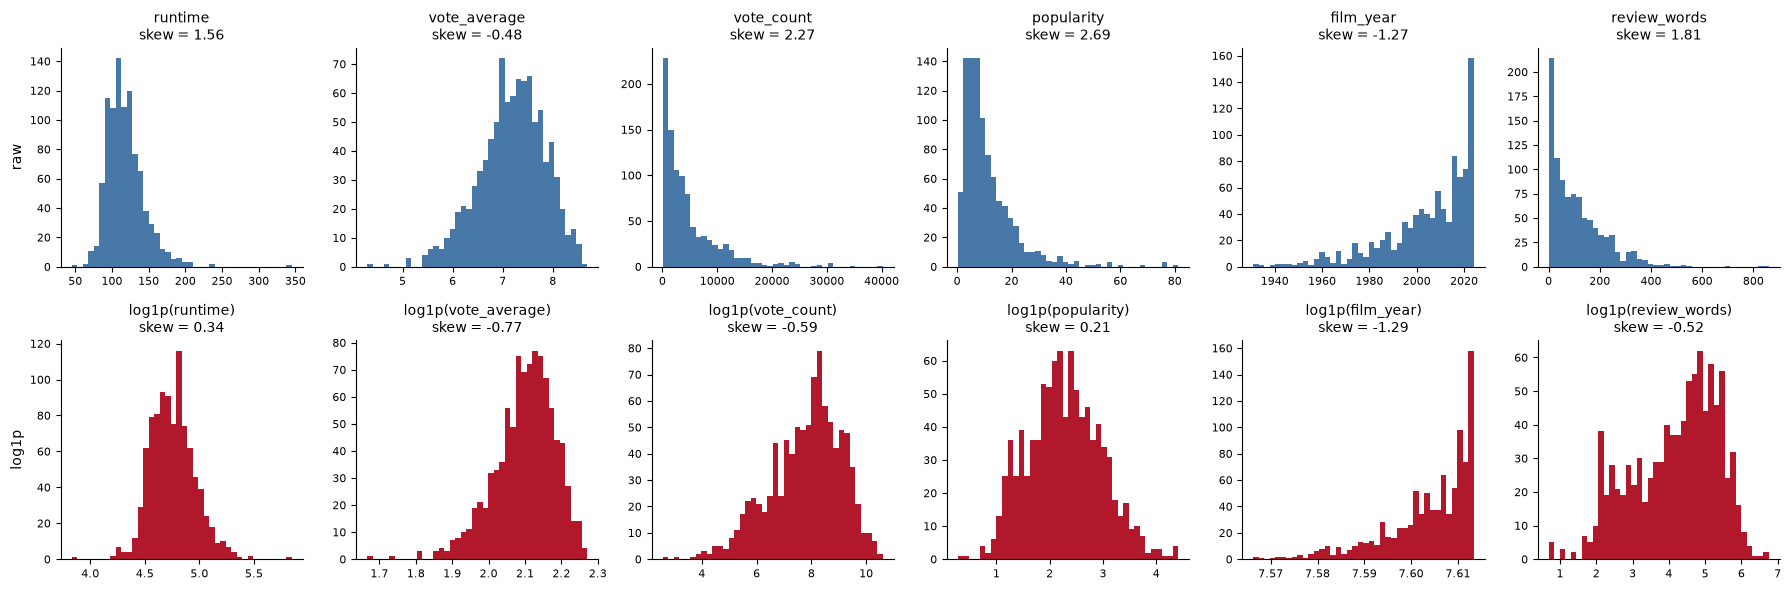

In [15]:
fig, axes = plt.subplots(2, len(CANDIDATES), figsize=(3 * len(CANDIDATES), 6))

for j, col in enumerate(CANDIDATES):
    raw = train[col].dropna()
    axes[0, j].hist(raw, bins=40, color="#4878a8")
    axes[0, j].set_title(f"{col}\nskew = {raw.skew():.2f}", fontsize=10)

    logged = np.log1p(raw)
    axes[1, j].hist(logged, bins=40, color="#b2182b")
    axes[1, j].set_title(f"log1p({col})\nskew = {logged.skew():.2f}", fontsize=10)

for ax in axes.flat:
    ax.tick_params(labelsize=8)
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)

axes[0, 0].set_ylabel("raw")
axes[1, 0].set_ylabel("log1p")
plt.tight_layout()
plt.show()

Reading the skew figures (near 0 is symmetric, above ~1 is substantially
right-skewed), the decision rule is whether logging moves skew *closer* to zero:

| Feature | raw | log1p | decision |
|---|---|---|---|
| `popularity` | 3.73 | 0.22 | **log** |
| `vote_count` | 2.27 | −0.59 | **log** |
| `review_words` | 1.81 | −0.52 | **log** |
| `runtime` | 1.56 | 0.34 | **log** |
| `vote_average` | −0.49 | −0.78 | plain — logging worsens it |
| `film_year` | −1.27 | −1.29 | plain — logging is meaningless here |

`runtime` was initially assumed symmetric from the summary statistics; the histogram
shows a clear right tail (the 345-minute Lav Diaz), and the skew figure confirms
logging helps.

**Why log rather than just scale.** `StandardScaler` is a linear transform — it
changes units but leaves the distribution's *shape* untouched, so a skewed variable
stays skewed. Ridge fits one coefficient across the whole range, which without logging
forces it to treat a 3,000-vote gap identically whether it separates 12 from 3,000
(meaningful) or 37,000 from 40,000 (meaningless). Logging makes equal *ratios* span
equal distances. Log first for shape, then scale for the L2 penalty.

`log1p` rather than `log` because it computes log(1+x) and handles zero safely —
`popularity` can be 0.

`film_year`'s −1.27 skew is real and untreated. Random Forest handles it natively;
if Ridge underperforms on older films, a decade bucket or `film_age` is the fallback.


In [16]:
LOG_NUMERIC = ["runtime", "vote_count", "popularity", "review_words"]
PLAIN_NUMERIC = ["vote_average", "film_year"]

def encode_numeric(frame):
    out = frame[PLAIN_NUMERIC].copy()
    for col in LOG_NUMERIC:
        out[f"log_{col}"] = np.log1p(frame[col])
    return out

n_train = encode_numeric(train)
print(n_train.describe().round(2))

       vote_average  film_year  log_runtime  log_vote_count  log_popularity  \
count        953.00     953.00       953.00          953.00          953.00   
mean           7.18    2004.60         4.75            7.80            2.27   
std            0.66      18.29         0.20            1.31            0.68   
min            4.29    1931.00         3.83            2.56            0.28   
25%            6.79    1996.00         4.62            7.00            1.80   
50%            7.23    2010.00         4.74            8.00            2.24   
75%            7.64    2019.00         4.88            8.75            2.74   
max            8.69    2024.00         5.85           10.60            4.41   

       log_review_words  
count            953.00  
mean               4.18  
std                1.18  
min                0.69  
25%                3.30  
50%                4.44  
75%                5.11  
max                6.76  


### Assemble Block F

6 numeric + 15 genre + 6 language + 1 franchise flag = 28 columns.

Deliberately excluded: **director, cast, cinematographer** (high-cardinality — they
enter as historical means in Block H), **keywords** and **overview** (held for Block
R), **`origin_country`** (near-duplicate of language).

So Model 2 answers "how much is predictable from what the film objectively *is*".
Everything about the viewer comes later.

Three checks in one cell because all three fail silently: mismatched column *order*
would misalign features without raising, and nulls surface later as an opaque `fit`
error.


In [17]:
def build_features_F(frame):
    """Block F — film metadata only."""
    return pd.concat([
        encode_numeric(frame),
        encode_genres(frame["genres"], GENRES),
        encode_categorical(frame["original_language"], LANGUAGES, "lang"),
        frame[["in_collection"]].astype(int),
    ], axis=1)

X_train = build_features_F(train)
X_test  = build_features_F(test)

print(f"train {X_train.shape}  test {X_test.shape}")
print(f"columns match: {list(X_train.columns) == list(X_test.columns)}")
print(f"nulls — train {X_train.isna().sum().sum()}, test {X_test.isna().sum().sum()}")

train (953, 28)  test (239, 28)
columns match: True
nulls — train 0, test 0
